In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import boto3
import sagemaker
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
import zarr
import s3fs
from utils import *

In [3]:
%store -r
%store

Stored variables and their in-db values:
default_bucket              -> 'sagemaker-us-east-1-298748835671'
s3_project_root             -> 'floorplan-generator'


# Creating Athena Database

In [4]:
sns.set_theme()

sess = sagemaker.Session()
bucket = sess.default_bucket()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
s3 = boto3.client("s3")

In [5]:
database_name = "room_metadata"
raw_dicts_table = "raw_dicts"
s3_project_prefix = f"s3://{default_bucket}/{s3_project_root}"

s3_staging_dir = f"{s3_project_prefix}/athena/staging/"

engine = create_engine(
    f"awsathena+rest://@athena.{region}.amazonaws.com:443/"
    f"{database_name}"
    f"?s3_staging_dir={s3_staging_dir}"
)

In [7]:
# Create database
statement = f"CREATE DATABASE IF NOT EXISTS {database_name}"
pd.read_sql(statement, engine)

""


In [5]:
# Verifying database creation
statement = "SHOW DATABASES"
pd.read_sql(statement, engine)

,database_name
0,cat_landmarking
1,default
2,room_metadata
3,sagemaker_featurestore


In [ ]:
s3://sagemaker-us-east-1-298748835671/floorplan-generator/metadata/metadata.parquet

In [6]:
s3.download_file(default_bucket, "floorplan-generator/metadata/metadata.parquet", "metadata.parquet")

In [7]:
metadata_df = pd.read_parquet("metadata.parquet")
metadata_df.shape

(80788, 10)

In [8]:
metadata_df.tail()

,sample_id,0,1,2,3,4,5,6,7,id
80783,sample_80783,"{'category': 0, 'centroid': [72, 143]}","{'category': 2, 'centroid': [44, 169]}","{'category': 11, 'centroid': [44, 208]}","{'category': 1, 'centroid': [156, 99]}","{'category': 3.0, 'centroid': [108, 70]}","{'category': 3.0, 'centroid': [101, 202]}","{'category': 9.0, 'centroid': [215, 74]}",None,9973.pkl
80784,sample_80784,"{'category': 9, 'centroid': [51, 52]}","{'category': 2, 'centroid': [51, 90]}","{'category': 7, 'centroid': [60, 192]}","{'category': 6, 'centroid': [75, 139]}","{'category': 0.0, 'centroid': [134, 123]}","{'category': 3.0, 'centroid': [106, 201]}","{'category': 1.0, 'centroid': [158, 193]}","{'category': 9.0, 'centroid': [210, 134]}",9983.pkl
80785,sample_80785,"{'category': 7, 'centroid': [74, 162]}","{'category': 9, 'centroid': [63, 78]}","{'category': 0, 'centroid': [131, 112]}","{'category': 2, 'centroid': [87, 78]}","{'category': 3.0, 'centroid': [115, 178]}","{'category': 1.0, 'centroid': [159, 169]}","{'category': 9.0, 'centroid': [197, 107]}",None,9993.pkl
80786,sample_80786,"{'category': 0, 'centroid': [96, 123]}","{'category': 2, 'centroid': [73, 186]}","{'category': 9, 'centroid': [104, 186]}","{'category': 3, 'centroid': [127, 172]}","{'category': 1.0, 'centroid': [148, 80]}","{'category': 7.0, 'centroid': [165, 122]}","{'category': 7.0, 'centroid': [165, 163]}","{'category': 9.0, 'centroid': [191, 77]}",9996.pkl
80787,sample_80787,"{'category': 2, 'centroid': [66, 71]}","{'category': 9, 'centroid': [66, 110]}","{'category': 7, 'centroid': [77, 181]}","{'category': 3, 'centroid': [73, 145]}","{'category': 0.0, 'centroid': [129, 122]}","{'category': 1.0, 'centroid': [153, 178]}","{'category': 9.0, 'centroid': [196, 117]}",None,9999.pkl


s3://sagemaker-us-east-1-298748835671/floorplan-generator/metadata/metadata.parquet

# Visualizing All Layers Stacked

In [71]:
# Get room vocab
vocab = get_vocab()
room_index = vocab["object_idx_to_name"]

# Open the S3 filesystem
fs = s3fs.S3FileSystem()

# Open the zarr store
store = s3fs.S3Map(root=f'{s3_project_prefix}/store/data.zarr', s3=fs, check=False)

# Open the zarr array or group
z = zarr.open(store, mode='r')

# Load sample
boundary_mask = z['boundary_masks'][1]
inside_mask = z['inside_masks'][1]
room_mask = z['room_masks'][1]
door_mask = z['door_masks'][1]

metadata = metadata_df.iloc[1, 1:-1]

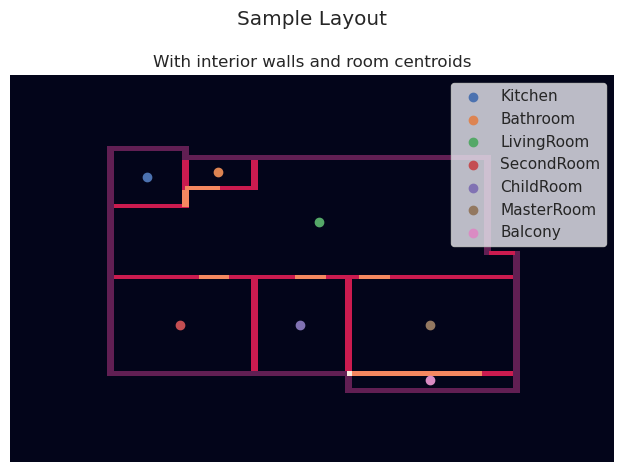

In [74]:
# recovering walls through elementise addition
fig, ax = plt.subplots()

sns.heatmap(np.sum([boundary_mask, room_mask*2, door_mask*3], axis=0), 
            cbar=False, xticklabels=False, yticklabels=False)

for room in metadata:
    if room:
        ax.scatter(
            room["centroid"][1], 
            room["centroid"][0],
            label=room_index[int(room["category"])]
            )

ax.set_title("With interior walls and room centroids")
ax.legend()

plt.suptitle("Sample Layout")
plt.tight_layout()
plt.show()

# Visualizing Individual Masks (Channels)

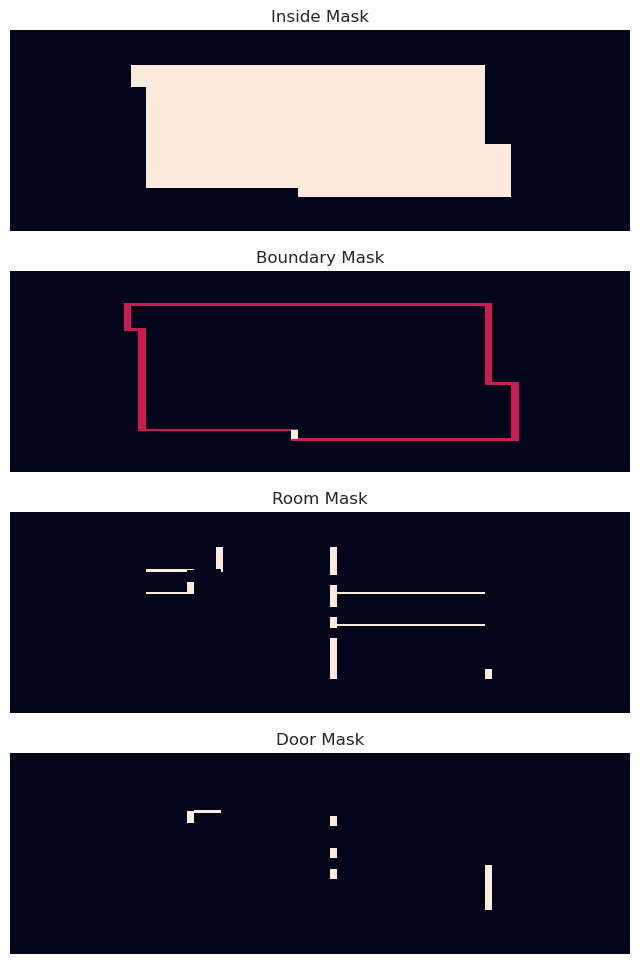

In [75]:
masks = [inside_mask, boundary_mask, room_mask, door_mask]

fig, ax = plt.subplots(len(masks), figsize=(8, 12))

for i, mask in enumerate(masks):
    sns.heatmap(mask.T, ax=ax[i], cbar=False, xticklabels=False, yticklabels=False)

ax[0].set_title("Inside Mask")
ax[1].set_title("Boundary Mask")
ax[2].set_title("Room Mask")
ax[3].set_title("Door Mask")

plt.show()